<a href="https://colab.research.google.com/github/Celeste1221/Data-Science-Cohort-20/blob/main/Project_2_Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2: Housing Price Prediction

## Problem Definition


We want to predict the sales price of a house based on previous sales of homes with similar features. This is a supervised regression problem with the target being the sales price (a continuous numerical value).

## Data Collection/Sources


This data is available at  https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv.

According to the data dictionary available at https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Housing%20-%20Data%20Documentation.pdf:

"SIZE: 2930 observations, 82 variables

DESCRIPTIVE ABSTRACT: Data set contains information from the
Assessor's Office used in computing assessed values for individual
residential properties sold from 2006 to 2010."

That said, the data dictionary number of observations does not match the number of observations in the dataset.

## Imports

In [1]:
import statsmodels.api as sm
import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn import preprocessing
from sklearn import datasets
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

## File Paths

In [2]:
# file path
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv'

In [3]:
# read csv into a pandas dataframe
df = pd.read_csv(url)

## Exploratory Data Analysis

Examine the data, handle nulls, unique IDs, duplicates, check correlations.

In [4]:
# number of rows and columns
df.shape

(2637, 81)

In [5]:
# printe the first 5 columns
df.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000


In [6]:
# check datatypes and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2637 non-null   int64  
 1   MS SubClass      2637 non-null   int64  
 2   MS Zoning        2637 non-null   object 
 3   Lot Frontage     2188 non-null   float64
 4   Lot Area         2637 non-null   int64  
 5   Street           2637 non-null   object 
 6   Alley            180 non-null    object 
 7   Lot Shape        2637 non-null   object 
 8   Land Contour     2637 non-null   object 
 9   Utilities        2637 non-null   object 
 10  Lot Config       2637 non-null   object 
 11  Land Slope       2637 non-null   object 
 12  Neighborhood     2637 non-null   object 
 13  Condition 1      2637 non-null   object 
 14  Condition 2      2637 non-null   object 
 15  Bldg Type        2637 non-null   object 
 16  House Style      2637 non-null   object 
 17  Overall Qual  

In [7]:
# get summary statistics
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
PID,2637.0,7.141301e+08,1.887527e+08,526301100.0,5.284770e+08,535453040.0,9.071870e+08,1.007100e+09
MS SubClass,2637.0,5.734926e+01,4.249909e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2188.0,6.916682e+01,2.335678e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2637.0,1.004469e+04,6.742550e+03,1300.0,7.436000e+03,9450.0,1.152600e+04,1.646600e+05
Overall Qual,2637.0,6.097459e+00,1.411522e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2637.0,5.569966e+00,1.118262e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2637.0,1.971289e+03,3.030699e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2637.0,1.984203e+03,2.091308e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2614.0,1.018879e+02,1.795782e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03
BsmtFin SF 1,2636.0,4.384412e+02,4.496023e+02,0.0,0.000000e+00,368.0,7.320000e+02,5.644000e+03


In [8]:
# get summary stats of the target column
df['SalePrice'].describe()

,SalePrice
count,2637.000000
mean,179986.230186
std,78309.251522
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213000.000000
max,745000.000000


In [9]:
# check for missing values in target column
df['SalePrice'].isna().sum()

np.int64(0)

In [10]:
# get target value_counts
df['SalePrice'].value_counts(dropna=False)

,count
SalePrice,
140000,31
135000,30
130000,28
155000,24
160000,22
...,...
160200,1
174190,1
415298,1


### Data Cleaning

In [11]:
print(df.dtypes)

PID                 int64
MS SubClass         int64
MS Zoning          object
Lot Frontage      float64
Lot Area            int64
                   ...   
Mo Sold             int64
Yr Sold             int64
Sale Type          object
Sale Condition     object
SalePrice           int64
Length: 81, dtype: object


In [12]:
# a data series of unique values in each column
nunique = df.nunique().sort_values(ascending=False)
nunique

,0
PID,2637
Lot Area,1799
Gr Liv Area,1216
Bsmt Unf SF,1080
1st Flr SF,1022
...,...
Bsmt Half Bath,3
Paved Drive,3
Street,2
Alley,2


In [13]:
# make a working copy
df_copy = df.copy()

In [14]:
# drop unique identifiers
df_copy.drop(columns='PID', inplace=True)

In [15]:
# drop the MS SubClass column
df_copy.drop(columns='MS SubClass', inplace=True)

In [16]:
# list the 25 columns with most missing values to least missing values
df.isna().sum().sort_values(ascending=False)[:25]

,0
Pool QC,2626
Misc Feature,2541
Alley,2457
Fence,2109
Mas Vnr Type,1607
Fireplace Qu,1284
Lot Frontage,449
Garage Yr Blt,147
Garage Cond,147
Garage Qual,147


In [17]:
# drop columns with missing values
df_copy = df_copy.dropna(axis=1)

In [18]:
df_copy.shape

(2637, 53)

In [19]:
df_copy.dtypes

,0
MS Zoning,object
Lot Area,int64
Street,object
Lot Shape,object
Land Contour,object
Utilities,object
Lot Config,object
Land Slope,object
Neighborhood,object
Condition 1,object


In [20]:
# separate numeric data
df_numeric = df_copy.select_dtypes(include='number')
df_numeric.dtypes

,0
Lot Area,int64
Overall Qual,int64
Overall Cond,int64
Year Built,int64
Year Remod/Add,int64
1st Flr SF,int64
2nd Flr SF,int64
Low Qual Fin SF,int64
Gr Liv Area,int64
Full Bath,int64


In [21]:
df_numeric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Lot Area         2637 non-null   int64
 1   Overall Qual     2637 non-null   int64
 2   Overall Cond     2637 non-null   int64
 3   Year Built       2637 non-null   int64
 4   Year Remod/Add   2637 non-null   int64
 5   1st Flr SF       2637 non-null   int64
 6   2nd Flr SF       2637 non-null   int64
 7   Low Qual Fin SF  2637 non-null   int64
 8   Gr Liv Area      2637 non-null   int64
 9   Full Bath        2637 non-null   int64
 10  Half Bath        2637 non-null   int64
 11  Bedroom AbvGr    2637 non-null   int64
 12  Kitchen AbvGr    2637 non-null   int64
 13  TotRms AbvGrd    2637 non-null   int64
 14  Fireplaces       2637 non-null   int64
 15  Wood Deck SF     2637 non-null   int64
 16  Open Porch SF    2637 non-null   int64
 17  Enclosed Porch   2637 non-null   int64
 18  3Ssn Por

In [22]:
# check numeric columns for correlation with SalePrice
print(df_numeric.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False).head(15))

SalePrice         1.000000
Overall Qual      0.805016
Gr Liv Area       0.705482
1st Flr SF        0.618247
Year Built        0.562777
Full Bath         0.542386
Year Remod/Add    0.539932
TotRms AbvGrd     0.493853
Fireplaces        0.468886
Wood Deck SF      0.322060
Open Porch SF     0.310361
Half Bath         0.287063
Lot Area          0.268516
2nd Flr SF        0.268059
Bedroom AbvGr     0.131789
Name: SalePrice, dtype: float64


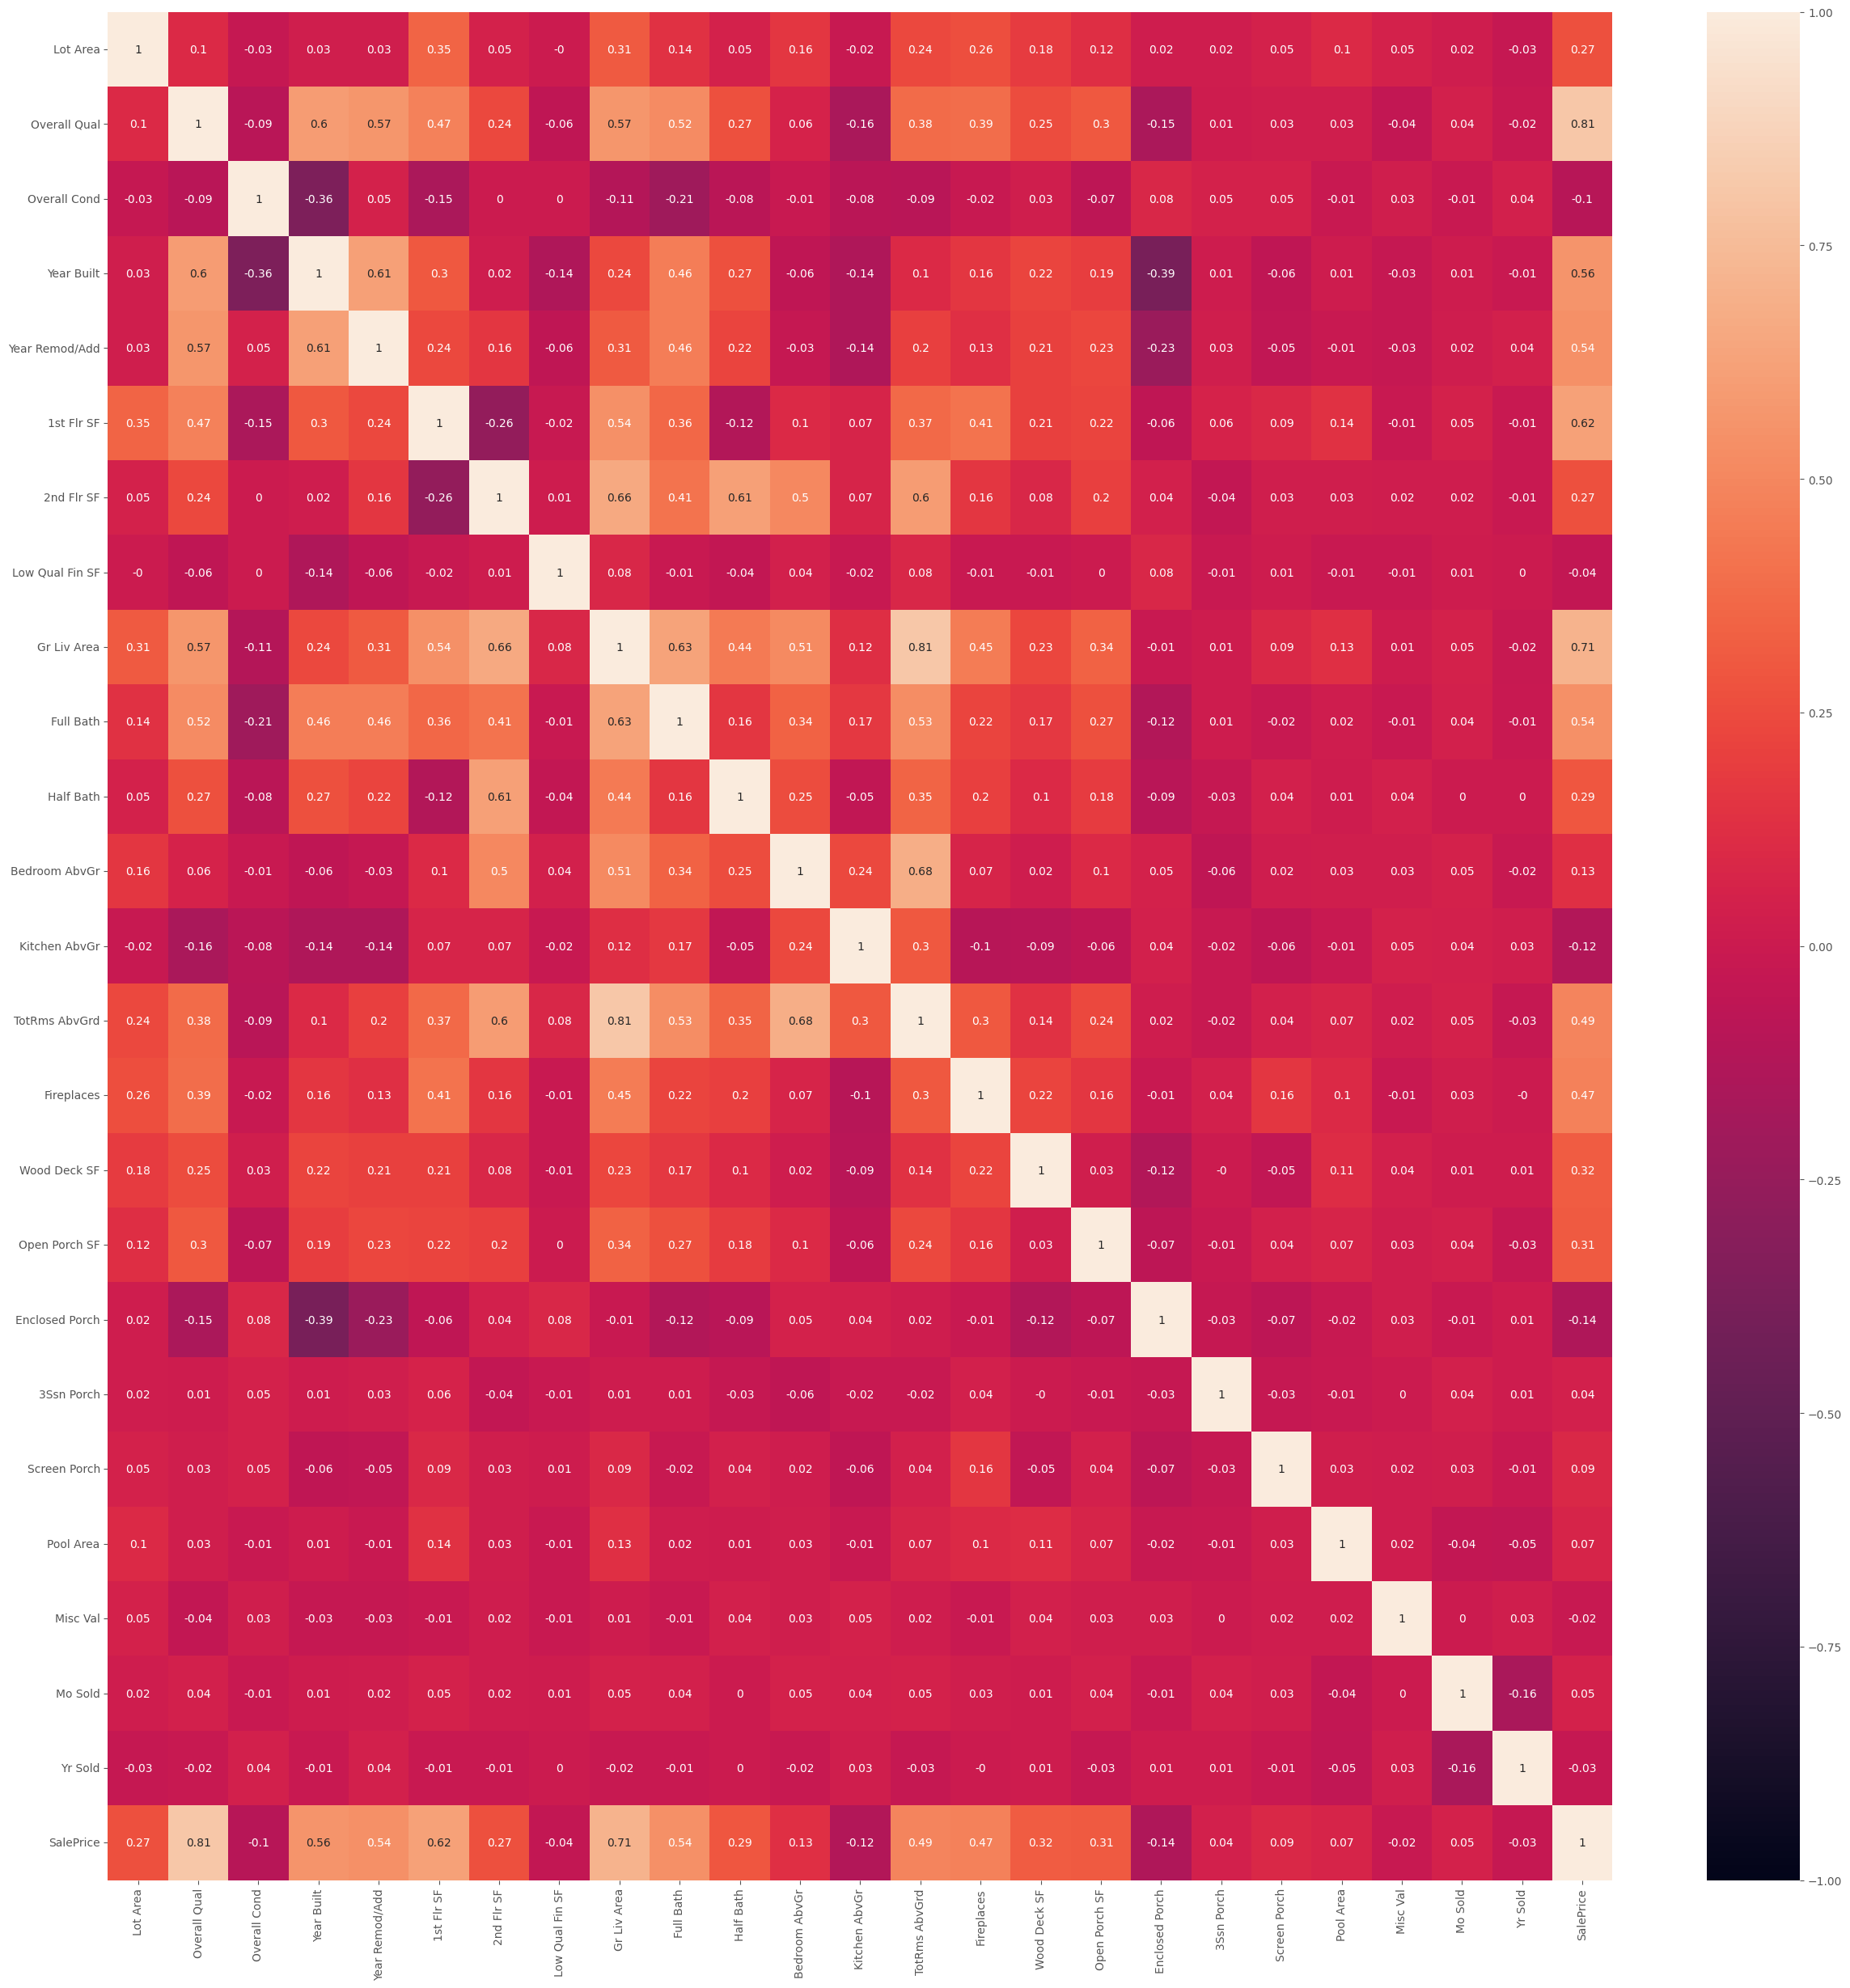

In [23]:
# correlation plot
plt.figure(figsize=(30,30))
correlation_matrix = df_numeric.corr().round(2)
sns.heatmap(data=correlation_matrix, annot=True, vmin=-1, vmax=1) ;

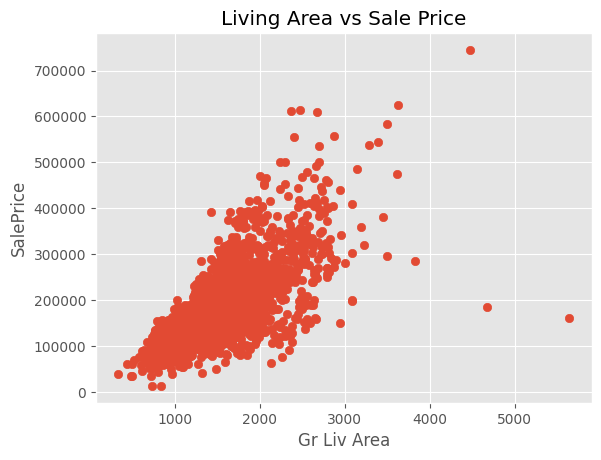

In [24]:
# check numeric relationships with target
plt.scatter(df["Gr Liv Area"], df["SalePrice"])
plt.xlabel("Gr Liv Area")
plt.ylabel("SalePrice")
plt.title("Living Area vs Sale Price")
plt.show()

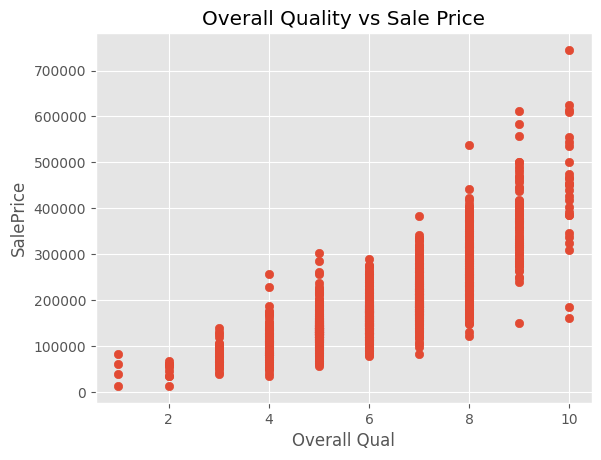

In [25]:
plt.scatter(df["Overall Qual"], df["SalePrice"])
plt.xlabel("Overall Qual")
plt.ylabel("SalePrice")
plt.title("Overall Quality vs Sale Price")
plt.show()

array([[<Axes: title={'center': 'Lot Area'}>,
        <Axes: title={'center': 'Overall Qual'}>,
        <Axes: title={'center': 'Overall Cond'}>,
        <Axes: title={'center': 'Year Built'}>,
        <Axes: title={'center': 'Year Remod/Add'}>],
       [<Axes: title={'center': '1st Flr SF'}>,
        <Axes: title={'center': '2nd Flr SF'}>,
        <Axes: title={'center': 'Low Qual Fin SF'}>,
        <Axes: title={'center': 'Gr Liv Area'}>,
        <Axes: title={'center': 'Full Bath'}>],
       [<Axes: title={'center': 'Half Bath'}>,
        <Axes: title={'center': 'Bedroom AbvGr'}>,
        <Axes: title={'center': 'Kitchen AbvGr'}>,
        <Axes: title={'center': 'TotRms AbvGrd'}>,
        <Axes: title={'center': 'Fireplaces'}>],
       [<Axes: title={'center': 'Wood Deck SF'}>,
        <Axes: title={'center': 'Open Porch SF'}>,
        <Axes: title={'center': 'Enclosed Porch'}>,
        <Axes: title={'center': '3Ssn Porch'}>,
        <Axes: title={'center': 'Screen Porch'}>],
      

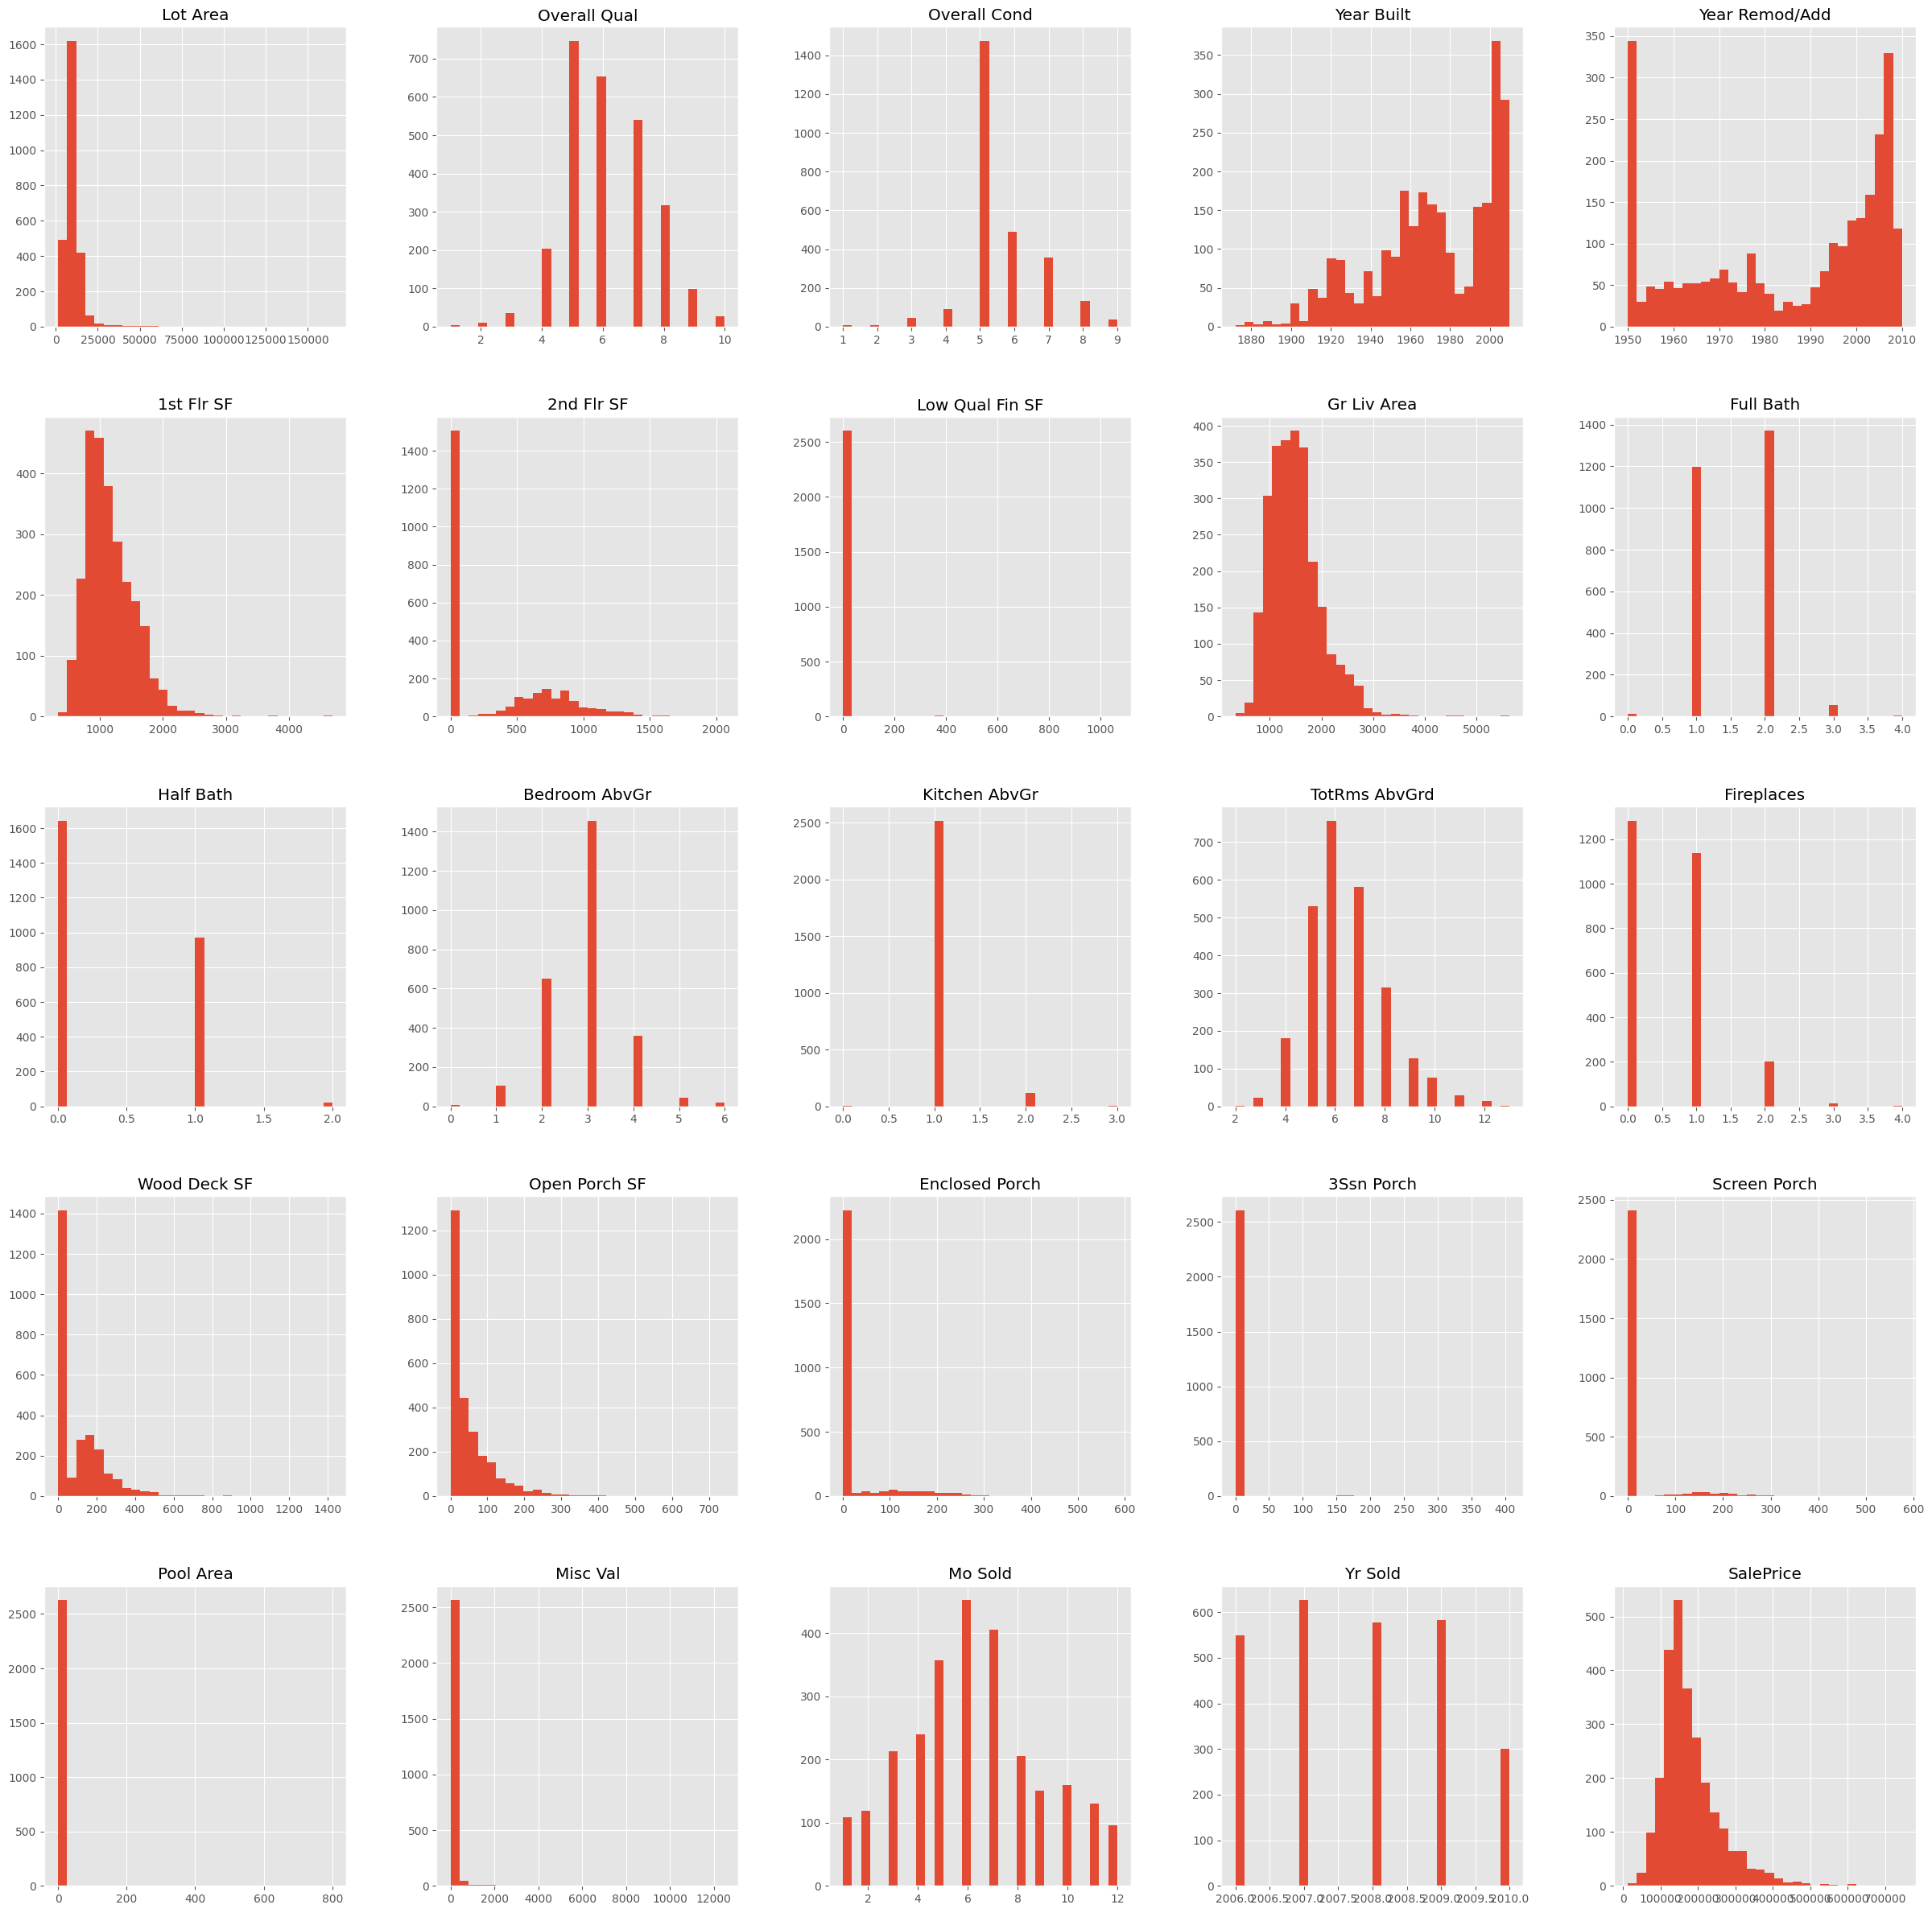

In [26]:
df_numeric.hist(bins=30, figsize=(30,30))

## Processing

The model used is a linear regression model with ridge regularization and robust scaling.

Linear regression assumes a linear relationship between the predictors and the target, no collinearity, residuals are normally distributed and independent.


In [27]:
# list of the features to train the model with
features = ['Overall Qual', 'Gr Liv Area', '1st Flr SF', 'Year Built',
            'Full Bath', 'Year Remod/Add', 'TotRms AbvGrd', 'Fireplaces']

### Scale the data first (makes sure the regularization penalty treats the features equally)

In [28]:
# make train and test datasets
X = df_copy[features]
y = df['SalePrice']

# scale the features
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [29]:
X_scaled.describe()

,Overall Qual,Gr Liv Area,1st Flr SF,Year Built,Full Bath,Year Remod/Add,TotRms AbvGrd,Fireplaces
count,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000
mean,0.048730,0.091479,0.146426,-0.036413,-0.440273,-0.225567,0.223360,-0.400834
std,0.705761,0.809166,0.762146,0.644829,0.550156,0.536233,0.784171,0.651052
min,-2.500000,-1.808824,-1.490040,-2.148936,-2.000000,-1.102564,-2.000000,-1.000000
25%,-0.500000,-0.511438,-0.406375,-0.404255,-1.000000,-0.717949,-0.500000,-1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.500000,0.488562,0.593625,0.595745,0.000000,0.282051,0.500000,0.000000
max,2.000000,6.864379,7.191235,0.787234,2.000000,0.435897,3.500000,3.000000


In [30]:
# create the testing and training sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
  y, test_size=0.2, random_state=4)

### Then regularize (because it will penalize large coefficients if the data hasn't been scaled) and train the model.

In [31]:
# Train the model with Ridge regularization
my_fit_rr = Ridge(alpha = 1) # alpha = 1 is arbitrary
my_fit_rr.fit(X_train, y_train)

Ridge(alpha=1)

In [32]:
# Calculate RMSE
y_pred = my_fit_rr.predict(X_test)
rmse = np.sqrt(np.mean(np.square(y_test - y_pred)))
print(f"RMSE: {rmse}")

RMSE: 34843.09962494894


In [33]:
# Calculate RMSPE
rmspe = np.sqrt(np.mean(np.square((y_test-y_pred) / y_test))) * 100
print(f"RMSPE: {rmspe:.2f}%")

RMSPE: 22.24%


## Data Visualization/Communication of Results


Text(0, 0.5, 'Predicted Sale Price')

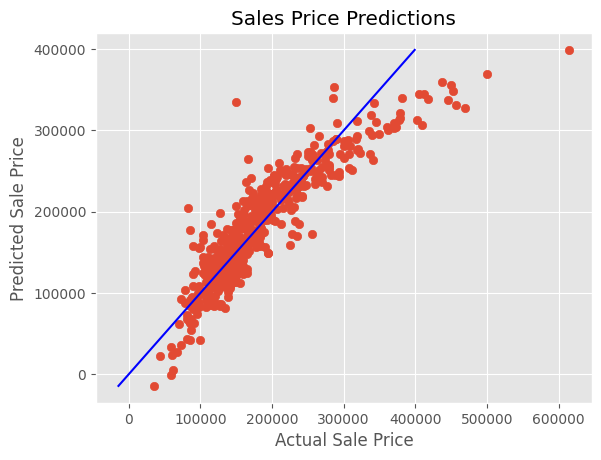

In [34]:
# See how well our model performs on our test data
y_pred = my_fit_rr.predict(X_test)
plt.scatter(y_test, y_pred)
plt.plot([min(y_pred), max(y_pred)],[min(y_pred), max(y_pred)], c='blue')
plt.title('Sales Price Predictions')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')


I used a linear regression model with robust scaling and ridge regression for scaling and regularization. Unique identifiers were handled by removing columns and missing values were handled by removing rows. There were no duplicates. After cleaning, features were chosen by comparing correlation between numerical columns and the target column, then choosing the top 8 correlated variables. The RMSPE is 22.24%.

Future ideas:
1. Encode the categorical variables and add some of them in to the training dataset.
2. Try different scaling and regularization methods.